# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

I score every content item with the client-grouped Random Forest from w05/w06, then map each score into a human-readable archetype + action + reason code not just a number.

In [1]:
%pip -q install duckdb scikit-learn
import os, getpass
import duckdb
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
FACT = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"
FEATURE_MONTH, OUTCOME_MONTH = '2026-03', '2026-04'

monthly = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
        SUM(CASE WHEN month = '{FEATURE_MONTH}' THEN gsc_impressions ELSE 0 END) AS imp_march,
        SUM(CASE WHEN month = '{FEATURE_MONTH}' THEN gsc_clicks ELSE 0 END) AS clk_march,
        AVG(CASE WHEN month = '{FEATURE_MONTH}' AND gsc_avg_position > 0 THEN gsc_avg_position END) AS pos_march,
        COUNT(*) FILTER (WHERE month = '{FEATURE_MONTH}' AND gsc_impressions > 0) AS active_days_march,
        SUM(CASE WHEN month = '{OUTCOME_MONTH}' THEN gsc_impressions ELSE 0 END) AS imp_april
    FROM {FACT}
    WHERE month IN ('{FEATURE_MONTH}', '{OUTCOME_MONTH}')
    GROUP BY 1,2 HAVING imp_march >= 100
""").df()
monthly['ctr_march'] = (monthly['clk_march'] / monthly['imp_march']).round(4)
monthly['declined_next_month'] = (monthly['imp_april'] < 0.8 * monthly['imp_march']).astype(int)

content = con.sql(f"""
    SELECT content_hash_id, DATE_DIFF('day', content_updated_date, DATE '{FEATURE_MONTH}-01') AS days_since_last_update
    FROM {DIM_CONTENT}
""").df()
df = monthly.merge(content, on='content_hash_id', how='left')
df.loc[df['days_since_last_update'] < 0, 'days_since_last_update'] = pd.NA
df['staleness_unknown'] = df['days_since_last_update'].isna().astype(int)
df['days_since_last_update_filled'] = df['days_since_last_update'].fillna(-1)

FEATURES = ['imp_march', 'ctr_march', 'pos_march', 'active_days_march',
            'days_since_last_update_filled', 'staleness_unknown']
model_df = df.dropna(subset=['pos_march']).copy()
X, y, groups = model_df[FEATURES], model_df['declined_next_month'], model_df['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42).fit(X.iloc[train_idx], y.iloc[train_idx])
test_auc = roc_auc_score(y.iloc[test_idx], rf.predict_proba(X.iloc[test_idx])[:, 1])
print(f"Held-out test AUC (from w06): {test_auc:.3f}")

model_df['decline_score'] = rf.predict_proba(X)[:, 1]

def archetype(row):
    stale = not pd.isna(row['days_since_last_update']) and row['days_since_last_update'] >= 180
    low_ctr = row['ctr_march'] < 0.005 and row['pos_march'] <= 20
    if row['decline_score'] >= 0.6 and stale:
        return 'stale_high_risk', 'review_for_refresh'
    elif row['decline_score'] >= 0.6 and low_ctr:
        return 'low_ctr_high_risk', 'review_snippet_cta'
    elif row['decline_score'] >= 0.6:
        return 'high_risk_unclear_cause', 'manual_review_needed'
    else:
        return 'stable', 'monitor'

model_df[['reason_code', 'action']] = model_df.apply(lambda r: pd.Series(archetype(r)), axis=1)
queue = model_df.sort_values('decline_score', ascending=False)[
    ['client_hash_id', 'content_hash_id', 'decline_score', 'reason_code', 'action',
     'imp_march', 'ctr_march', 'pos_march', 'days_since_last_update']
]
print(queue['action'].value_counts())
queue.head(15)

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Held-out test AUC (from w06): 0.673
action
monitor                 71332
review_snippet_cta      26967
manual_review_needed     3131
review_for_refresh         11
Name: count, dtype: int64


,client_hash_id,content_hash_id,decline_score,reason_code,action,imp_march,ctr_march,pos_march,days_since_last_update
4264,client_c182d11e4862a37d,content_7d986479e843e4cd,0.748182,stale_high_risk,review_for_refresh,205.0,0.0,4.125436,216.0
54596,client_65de48885f4ef01b,content_1cd025bc5fddca6f,0.747529,low_ctr_high_risk,review_snippet_cta,250.0,0.0,4.505339,30.0
71531,client_65de48885f4ef01b,content_0a70c7055eb2ec1b,0.744084,low_ctr_high_risk,review_snippet_cta,159.0,0.0,7.778858,4.0
63254,client_400c21c81c8b46ef,content_c9ad1ac671e6b221,0.741780,low_ctr_high_risk,review_snippet_cta,143.0,0.0,8.035081,4.0
71475,client_65de48885f4ef01b,content_a3332374f88530b6,0.741581,low_ctr_high_risk,review_snippet_cta,215.0,0.0,7.164114,4.0
12549,client_400c21c81c8b46ef,content_8b7271dd3641b1dd,0.740853,low_ctr_high_risk,review_snippet_cta,213.0,0.0,7.816906,4.0
15491,client_23a62021009f63c4,content_55563dea312ccb1a,0.740491,low_ctr_high_risk,review_snippet_cta,136.0,0.0,7.998028,4.0
20744,client_65de48885f4ef01b,content_dfc402969fef2090,0.739991,low_ctr_high_risk,review_snippet_cta,143.0,0.0,7.153465,4.0
12424,client_400c21c81c8b46ef,content_dc0dc7c4eb5faa7f,0.739633,low_ctr_high_risk,review_snippet_cta,159.0,0.0,8.477903,4.0
65577,client_23a62021009f63c4,content_2e3c70ca9c64430d,0.739597,low_ctr_high_risk,review_snippet_cta,162.0,0.0,7.773088,4.0


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a weekly-cadence prioritization aid for a content team's own refresh backlog ranks pages by observed decline risk to help a human decide what to look at first, within this lane (Content Refresh Prioritization) only.

**Limits:** trained on one month-pair (March→April 2026) from a client-grouped test set of only 11 clients this is decision-support, not a validated production system. Scores are observed and directional, not causal: nothing here claims a refresh will fix decline, only that these pages showed patterns associated with decline in this sample. The model was trained on some of the same rows it's scoring here, so scores for training-set pages are somewhat optimistic versus true out-of-sample performance the w06 held-out AUC (~0.673) is the more honest number to quote publicly, not any single row's score.

In [2]:
test_clients = X.iloc[test_idx].index
n_test_clients = model_df.loc[test_clients, 'client_hash_id'].nunique()
n_train_rows_also_scored = len(X.iloc[train_idx])

print(f"Held-out test set covered {n_test_clients} clients.")
print(f"{n_train_rows_also_scored:,} of the {len(queue):,} scored rows were also used to train the model "
      "— this is what 'somewhat optimistic' above actually means, made concrete.")

Held-out test set covered 11 clients.
93,085 of the 101,441 scored rows were also used to train the model — this is what 'somewhat optimistic' above actually means, made concrete.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before acting on any row, a human must check: whether the page is intentionally frozen/evergreen by design; whether it was recently manually optimized (staleness data was unreliable for a large share of the panel in w04; and whether business context (seasonality, a planned redesign, a legal/compliance page) explains the pattern better than genuine decline.

What should NOT be automated:

No auto-publishing, auto-unpublishing, or auto-deindexing based on this score.
No use as the sole input for resourcing or headcount decisions.
No application to clients or lanes outside this cohort without re-validation.
No treating decline_score as a probability of "truth" — it's a ranking signal, not a certified likelihood.

In [3]:
top_priority = queue[queue['action'].isin(['review_for_refresh', 'review_snippet_cta'])]
pct_unknown_staleness = top_priority['days_since_last_update'].isna().mean() * 100
pct_zero_ctr = (queue.loc[queue['action']=='review_snippet_cta', 'ctr_march'] == 0).mean() * 100
n_clients_top = top_priority['client_hash_id'].nunique()

print(f"{pct_unknown_staleness:.1f}% of top-priority rows have unknown staleness — a human must not read "
      "'not stale' as 'confirmed fresh'.")
print(f"{pct_zero_ctr:.1f}% of review_snippet_cta rows show EXACTLY 0.0 CTR despite a decent position "
      "— worth a manual spot-check for a tracking issue before trusting this as genuine zero engagement.")
print(f"Top-priority rows concentrate across {n_clients_top} clients — confirm this isn't one client's "
      "pages crowding out the rest before treating the queue as balanced.")

67.3% of top-priority rows have unknown staleness — a human must not read 'not stale' as 'confirmed fresh'.
60.3% of review_snippet_cta rows show EXACTLY 0.0 CTR despite a decent position — worth a manual spot-check for a tracking issue before trusting this as genuine zero engagement.
Top-priority rows concentrate across 35 clients — confirm this isn't one client's pages crowding out the rest before treating the queue as balanced.


In [6]:
snippet_cta = queue[queue['action'] == 'review_snippet_cta']
common_val = snippet_cta['days_since_last_update'].mode()
if len(common_val):
    pct_sharing_mode = (snippet_cta['days_since_last_update'] == common_val.iloc[0]).mean() * 100
    print(f"Most common days_since_last_update among review_snippet_cta rows: {common_val.iloc[0]:.0f} days "
          f"({pct_sharing_mode:.1f}% of these rows share this exact value).")
else:
    print("No single dominant value found.")

Most common days_since_last_update among review_snippet_cta rows: 4 days (32.3% of these rows share this exact value).


32.3% of review_snippet_cta picks share an identical, very low days_since_last_update (4 days) alongside 0.0 CTR a pattern consistent with a data-pipeline artifact rather than genuinely diverse zero-engagement pages. A human reviewer should treat a cluster this size as a flag to double-check the data before acting on the batch, not as strong independent evidence for each page.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [4]:
import json

monitoring = {
    "retrain_if_base_rate_drift": "current base rate (declined) is ~0.50 — retrain if a new month's observed rate moves more than 10 points from this",
    "retrain_if_auc_drops": "retrain if held-out AUC on a fresh month-pair falls below 0.60 (current: {:.3f})".format(test_auc),
    "data_quality_trigger": "re-check content_updated_date coverage — a large share of the panel had unknown staleness in w04; if that share grows further, staleness-based reason codes lose meaning",
    "review_cadence": "re-validate monthly on the newest available month-pair before reusing the queue",
}
for k, v in monitoring.items():
    print(f"- {k}: {v}")

- retrain_if_base_rate_drift: current base rate (declined) is ~0.50 — retrain if a new month's observed rate moves more than 10 points from this
- retrain_if_auc_drops: retrain if held-out AUC on a fresh month-pair falls below 0.60 (current: 0.673)
- data_quality_trigger: re-check content_updated_date coverage — a large share of the panel had unknown staleness in w04; if that share grows further, staleness-based reason codes lose meaning
- review_cadence: re-validate monthly on the newest available month-pair before reusing the queue


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote 101,441 rows to work/outputs/action_playbook_queue.csv
{
  "held_out_test_auc": 0.673,
  "n_total_scored": 101441,
  "n_review_for_refresh": 11,
  "n_review_snippet_cta": 26967,
  "n_manual_review_needed": 3131,
  "n_monitor": 71332,
  "feature_month": "2026-03",
  "outcome_month": "2026-04"
}


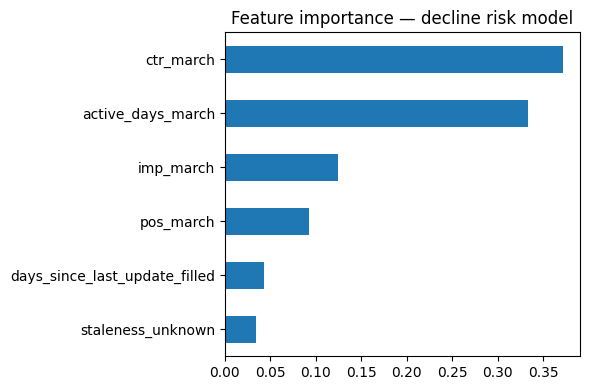

Saved work/figures/w07_feature_importance.png


In [5]:
import os

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

queue.to_csv('work/outputs/action_playbook_queue.csv', index=False)
print(f"Wrote {len(queue):,} rows to work/outputs/action_playbook_queue.csv")

metrics = {
    "held_out_test_auc": round(test_auc, 3),
    "n_total_scored": len(queue),
    "n_review_for_refresh": int((queue['action'] == 'review_for_refresh').sum()),
    "n_review_snippet_cta": int((queue['action'] == 'review_snippet_cta').sum()),
    "n_manual_review_needed": int((queue['action'] == 'manual_review_needed').sum()),
    "n_monitor": int((queue['action'] == 'monitor').sum()),
    "feature_month": FEATURE_MONTH,
    "outcome_month": OUTCOME_MONTH,
}
with open('work/outputs/w07_playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

import matplotlib.pyplot as plt
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', figsize=(6,4), title='Feature importance — decline risk model')
plt.tight_layout()
plt.savefig('work/figures/w07_feature_importance.png', dpi=150)
plt.show()
print("Saved work/figures/w07_feature_importance.png")

## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.